# Tank Anomaly Detection — LSTM Autoencoder
**Dataset:** Physical Refinery — 6 Tanks  
**Model:** LSTM Autoencoder  
**Target:** Sudden spike detection  
**Interval:** 1 reading per minute  
**Sequence window:** 30 minutes

## Install Dependencies

In [ ]:
!pip install pandas numpy scikit-learn matplotlib seaborn joblib tensorflow==2.16.1

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 589.9/589.9 MB 934.5 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 71.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 48.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 80.4 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.6
    Uninstalling protobuf-5.29.6:
      Successfully uninstalled protobuf-5.29.6
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: tensorboard
    Found existing installation: tensorboard 2.19.0
    Uninstalling tensorboard-2.19.0:
      Successfully uninstalled tensorboard-2.19.0
  Attempting uninstall: ml-dtypes
    F

In [ ]:
!pip install ml_dtypes==0.5.0

## Imports & Config

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Input, LSTM, RepeatVector, TimeDistributed, Dense
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import joblib
import warnings
warnings.filterwarnings('ignore')

# ── CONFIG ───────────────────────────────────────────────
CSV_FILE        = '/content/physical_7_to_13_dataset.csv'
TANK_MAX_LEVELS = {
    'physical_07': 15.0,
    'physical_08': 25.0,
    'physical_09': 25.0,
    'physical_11': 50.0,
    'physical_12': 50.0,
    'physical_13': 50.0
}
W               = 60       # rolling stats window (1 hour)
SPIKE_THRESHOLD = 1.5      # max ft change per 1-min reading
Z_THRESHOLD     = 4
SEQ_LEN         = 30       # 30-min sequence window for LSTM
BATCH_SIZE      = 256      # large batch for GPU
EPOCHS          = 50
THRESHOLD_PCT   = 95       # reconstruction error percentile for anomaly

# GPU check
gpus = tf.config.list_physical_devices('GPU')
print(f'GPUs available: {len(gpus)}')
if gpus:
    print(f'GPU: {gpus[0]}')
else:
    print('No GPU found — will use CPU (slower)')
print(f'TensorFlow version: {tf.__version__}')

GPUs available: 0
No GPU found — will use CPU (slower)
TensorFlow version: 2.16.1


---
## Step 1 — Load Dataset

In [ ]:
df = pd.read_csv(CSV_FILE)
df = df.rename(columns={
    'Date Time'             : 'datetime',
    'TankOilLevelInFeet001' : 'level_feet',
    'Physical Refinery'     : 'tank_id'
})
df['level_feet'] = pd.to_numeric(df['level_feet'], errors='coerce')
print(f'Rows  : {len(df):,}')
print(f'Tanks : {sorted(df["tank_id"].unique())}')
df.head()

Rows  : 53,536
Tanks : ['physical_07', 'physical_08', 'physical_09', 'physical_11', 'physical_12', 'physical_13']


,datetime,level_feet,tank_id
0,06:59 PM - 15/03/2026,12.106300,physical_07
1,06:58 PM - 15/03/2026,12.106300,physical_07
2,06:57 PM - 15/03/2026,12.106300,physical_07
3,06:55 PM - 15/03/2026,12.106300,physical_07
4,06:54 PM - 15/03/2026,12.073491,physical_07


---
## Step 2 — Parse Mixed Datetime Formats

In [ ]:
def parse_dt(val):
    val = str(val).strip()
    for fmt in [
        '%I:%M %p - %d/%m/%Y',
        '%m/%d/%Y %H:%M',
        '%d/%m/%Y %H:%M',
        '%Y-%m-%d %H:%M:%S',
        '%Y-%m-%d %H:%M',
    ]:
        try:
            return pd.to_datetime(val, format=fmt)
        except:
            continue
    return pd.NaT

df['datetime'] = df['datetime'].apply(parse_dt)
failed = df['datetime'].isna().sum()
print(f'Parsed OK: {len(df)-failed:,} | Failed: {failed}')
df = df.dropna(subset=['datetime'])
df = df.sort_values(['tank_id','datetime']).reset_index(drop=True)
print(f'Date range: {df["datetime"].min()} to {df["datetime"].max()}')

Parsed OK: 53,536 | Failed: 0
Date range: 2026-03-09 00:00:00 to 2026-03-15 18:59:00


---
## Step 3 — Clean Bad Values

In [ ]:
df['is_bad'] = 0
df.loc[df['level_feet'].isna(),     'is_bad'] = 1
df.loc[df['level_feet'] < 0,        'is_bad'] = 1
df.loc[df['level_feet'] > 30,       'is_bad'] = 1

df['prev_level'] = df.groupby('tank_id')['level_feet'].shift(1)
df.loc[(df['level_feet']==0)&(df['prev_level']>1), 'is_bad'] = 1

df['roc_raw'] = df.groupby('tank_id')['level_feet'].diff().abs()
df.loc[df['roc_raw'] > SPIKE_THRESHOLD, 'is_bad'] = 1

df.loc[df['is_bad']==1, 'level_feet'] = np.nan
df['level_feet'] = (
    df.groupby('tank_id')['level_feet']
      .transform(lambda x: x.interpolate(method='linear', limit=10))
)
df['level_feet'] = (
    df.groupby('tank_id')['level_feet']
      .transform(lambda x: x.fillna(x.mean()))
)
print(f'Bad readings fixed: {df["is_bad"].sum():,}')
df.groupby('tank_id')['is_bad'].sum().rename('bad_count')

Bad readings fixed: 18,057


,bad_count
tank_id,
physical_07,15
physical_08,20
physical_09,36
physical_11,0
physical_12,9085
physical_13,8901


---
## Step 4 — Feature Engineering

In [ ]:
feature_parts = []
for tank_id, group in df.groupby('tank_id'):
    g = group.copy()
    current_max = TANK_MAX_LEVELS[tank_id]
    g['headspace']     = current_max - g['level_feet']
    g['fill_pct']      = (g['level_feet'] / current_max) * 100
    g['roc']           = g['level_feet'].diff().fillna(0)
    g['roc_abs']       = g['roc'].abs()
    g['accel']         = g['roc'].diff()
    g['roll_mean']     = g['level_feet'].rolling(W, min_periods=1).mean()
    g['roll_std']      = g['level_feet'].rolling(W, min_periods=1).std().fillna(0)
    g['roll_range']    = g['level_feet'].rolling(W, min_periods=1).max() - g['level_feet'].rolling(W, min_periods=1).min()
    g['dev_from_mean'] = g['level_feet'] - g['roll_mean']
    mu                 = g['level_feet'].mean()
    sig                = g['level_feet'].std() + 1e-9
    g['z_score']       = (g['level_feet'] - mu) / sig
    g['hour']          = g['datetime'].dt.hour
    g['minute']        = g['datetime'].dt.minute
    g['day_of_week']   = g['datetime'].dt.dayofweek
    g['is_night']      = ((g['hour']>=22)|(g['hour']<=5)).astype(int)
    g['tank_id']       = tank_id
    feature_parts.append(g)

df = pd.concat(feature_parts, ignore_index=True)
df = df.fillna(0)
print(f'Shape: {df.shape}')

Shape: (53536, 20)


---
## Step 5 — Scale Features
LSTM requires values between 0 and 1. We scale per-tank so each tank's normal range is preserved.

In [ ]:
FEATURES = [
    'level_feet', 'headspace',  'fill_pct',
    'roc',        'roc_abs',    'accel',
    'roll_mean',  'roll_std',   'roll_range',
    'dev_from_mean','z_score',  'hour',
    'minute',     'day_of_week','is_night'
]
N_FEATURES = len(FEATURES)

# Scale per tank — each tank gets its own scaler
scalers = {}
scaled_parts = []

for tank_id, group in df.groupby('tank_id'):
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled = scaler.fit_transform(group[FEATURES])
    scalers[tank_id] = scaler
    tmp = pd.DataFrame(scaled, columns=FEATURES, index=group.index)
    tmp['tank_id']  = tank_id
    tmp['datetime'] = group['datetime'].values
    tmp['is_bad']   = group['is_bad'].values
    scaled_parts.append(tmp)

df_scaled = pd.concat(scaled_parts).sort_values(['tank_id','datetime']).reset_index(drop=True)
print(f'Scaled shape: {df_scaled.shape}')
print(f'Per-tank scalers saved: {list(scalers.keys())}')

Scaled shape: (53536, 18)
Per-tank scalers saved: ['physical_07', 'physical_08', 'physical_09', 'physical_11', 'physical_12', 'physical_13']


---
## Step 6 — Build Sequences
Each sequence = 30 consecutive readings (30 minutes).  
The LSTM learns what a normal 30-min window looks like.  
At inference, high reconstruction error = anomaly.

In [ ]:
def build_sequences(data, seq_len):
    """
    Slide a window of seq_len over the data.
    Returns array of shape (n_sequences, seq_len, n_features)
    """
    sequences = []
    for i in range(len(data) - seq_len + 1):
        sequences.append(data[i : i + seq_len])
    return np.array(sequences)

# Build sequences per tank (never mix tanks)
X_train_list = []
X_all_list   = []
meta_list    = []

for tank_id, group in df_scaled.groupby('tank_id'):
    values   = group[FEATURES].values
    is_bad   = group['is_bad'].values
    datetimes= group['datetime'].values

    seqs     = build_sequences(values,  SEQ_LEN)
    bad_seqs = build_sequences(is_bad,  SEQ_LEN)    # flag if any bad in window
    dt_seqs  = build_sequences(datetimes, SEQ_LEN)  # last timestamp of window

    # Training: only clean sequences (no bad readings in window)
    clean_mask = bad_seqs.sum(axis=1) == 0
    X_train_list.append(seqs[clean_mask])

    X_all_list.append(seqs)

    # Meta for each sequence: tank_id + last timestamp
    for j in range(len(seqs)):
        meta_list.append({
            'tank_id' : tank_id,
            'datetime': dt_seqs[j, -1],   # last timestamp in window
            'has_bad' : int(bad_seqs[j].sum() > 0)
        })

X_train = np.vstack(X_train_list)
X_all   = np.vstack(X_all_list)
meta_df = pd.DataFrame(meta_list)

print(f'X_train shape : {X_train.shape}  (clean sequences only)')
print(f'X_all shape   : {X_all.shape}   (all sequences)')
print(f'Sequence shape: (n_sequences, seq_len={SEQ_LEN}, n_features={N_FEATURES})')

# Shuffle training data
idx = np.random.permutation(len(X_train))
X_train = X_train[idx]

X_train shape : (34622, 30, 15)  (clean sequences only)
X_all shape   : (53362, 30, 15)   (all sequences)
Sequence shape: (n_sequences, seq_len=30, n_features=15)


---
## Step 7 — Build LSTM Autoencoder
```
Input (30, 15)
    └─► LSTM Encoder (64) ──► LSTM Encoder (32)
                                     │
                              Bottleneck (32)
                                     │
                         RepeatVector(30)
                                     │
              LSTM Decoder (32) ──► LSTM Decoder (64)
                                     │
                         TimeDistributed Dense(15)
                                     │
                            Output (30, 15)
```
Reconstruction error (MAE) per sequence = anomaly score.

In [ ]:
def build_lstm_autoencoder(seq_len, n_features):
    inputs = Input(shape=(seq_len, n_features), name='encoder_input')

    # ── Encoder ──────────────────────────────────────────
    x = LSTM(64, activation='relu', return_sequences=True,
             name='encoder_lstm1')(inputs)
    x = LSTM(32, activation='relu', return_sequences=False,
             name='encoder_lstm2')(x)      # bottleneck

    # ── Decoder ──────────────────────────────────────────
    x = RepeatVector(seq_len, name='repeat')(x)
    x = LSTM(32, activation='relu', return_sequences=True,
             name='decoder_lstm1')(x)
    x = LSTM(64, activation='relu', return_sequences=True,
             name='decoder_lstm2')(x)
    outputs = TimeDistributed(Dense(n_features), name='output')(x)

    model = Model(inputs, outputs, name='lstm_autoencoder')
    model.compile(optimizer='adam', loss='mae')
    return model

model = build_lstm_autoencoder(SEQ_LEN, N_FEATURES)
model.summary()

Model: "lstm_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 30, 15)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_lstm1 (LSTM)            │ (None, 30, 64)         │        20,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_lstm2 (LSTM)            │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat (RepeatVector)           │ (None, 30, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_lstm1 (LSTM)            │ (None, 30, 32)         │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_lstm2 (LSTM)            │ (None, 30, 64)         │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (TimeDistributed)        │ (None, 30, 15)         │           975 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 67,023 (261.81 KB)

 Trainable params: 67,023 (261.81 KB)

 Non-trainable params: 0 (0.00 B)

---
## Step 8 — Train Model

In [ ]:
# Split train/val
X_tr, X_val = train_test_split(X_train, test_size=0.1, random_state=42)
print(f'Train: {X_tr.shape} | Val: {X_val.shape}')

callbacks = [
    EarlyStopping(
        monitor   = 'val_loss',
        patience  = 5,           # stop if no improvement for 5 epochs
        restore_best_weights = True
    ),
    ModelCheckpoint(
        'tank_lstm_best.keras',
        monitor   = 'val_loss',
        save_best_only = True
    )
]

history = model.fit(
    X_tr, X_tr,                  # autoencoder: input = output
    validation_data = (X_val, X_val),
    epochs          = EPOCHS,
    batch_size      = BATCH_SIZE, # 256 for GPU
    callbacks       = callbacks,
    shuffle         = True,
    verbose         = 1
)

Train: (31159, 30, 15) | Val: (3463, 30, 15)
Epoch 1/50
122/122 ━━━━━━━━━━━━━━━━━━━━ 28s 184ms/step - loss: 0.1702 - val_loss: 0.0867
Epoch 2/50
122/122 ━━━━━━━━━━━━━━━━━━━━ 40s 176ms/step - loss: 0.0702 - val_loss: 0.0594
Epoch 3/50
122/122 ━━━━━━━━━━━━━━━━━━━━ 21s 175ms/step - loss: 0.0523 - val_loss: 0.0468
Epoch 4/50
122/122 ━━━━━━━━━━━━━━━━━━━━ 21s 176ms/step - loss: 0.0470 - val_loss: 0.0472
Epoch 5/50
122/122 ━━━━━━━━━━━━━━━━━━━━ 21s 170ms/step - loss: 0.0446 - val_loss: 0.0414
Epoch 6/50
122/122 ━━━━━━━━━━━━━━━━━━━━ 22s 181ms/step - loss: 0.0412 - val_loss: 0.0404
Epoch 7/50
122/122 ━━━━━━━━━━━━━━━━━━━━ 22s 178ms/step - loss: 0.0402 - val_loss: 0.0379
Epoch 8/50
122/122 ━━━━━━━━━━━━━━━━━━━━ 20s 166ms/step - loss: 0.0370 - val_loss: 0.0368
Epoch 9/50
122/122 ━━━━━━━━━━━━━━━━━━━━ 22s 180ms/step - loss: 0.0358 - val_loss: 0.0365
Epoch 10/50
122/122 ━━━━━━━━━━━━━━━━━━━━ 21s 172ms/step - loss: 0.0348 - val_loss: 0.0347
Epoch 11/50
122/122 ━━━━━━━━━━━━━━━━━━━━ 42s 177ms/step - loss: 

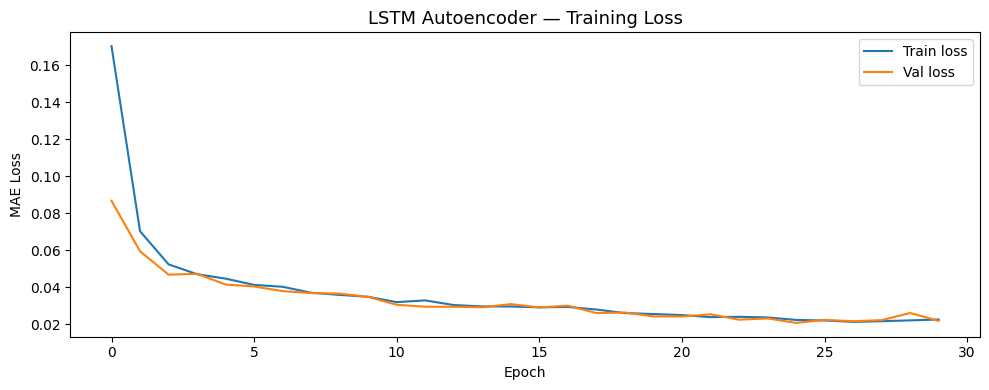

Best val loss: 0.020703


In [ ]:
# Plot training loss
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'],     label='Train loss')
plt.plot(history.history['val_loss'], label='Val loss')
plt.title('LSTM Autoencoder — Training Loss', fontsize=13)
plt.xlabel('Epoch')
plt.ylabel('MAE Loss')
plt.legend()
plt.tight_layout()
plt.show()
print(f'Best val loss: {min(history.history["val_loss"]):.6f}')

---
## Step 9 — Set Anomaly Threshold
Threshold = 95th percentile of reconstruction error on clean training data.  
Any sequence with error above this = anomaly.

Reconstruction error stats on clean data:
  Mean   : 0.020618
  Std    : 0.016064
  95th % : 0.053607  ← anomaly threshold


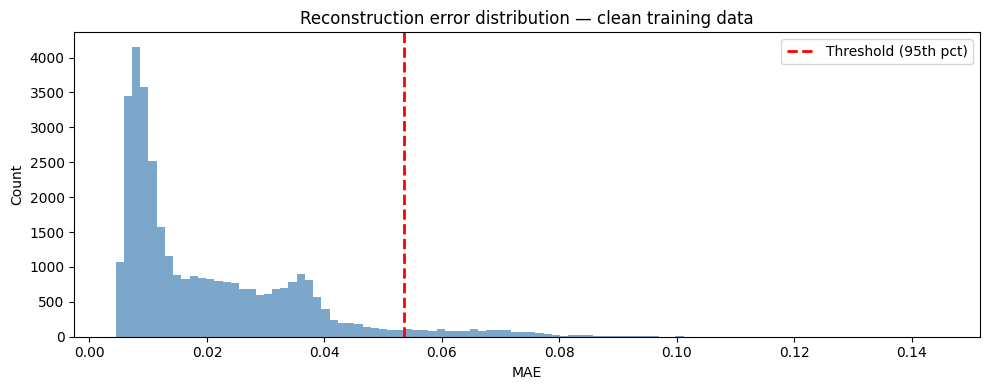

In [ ]:
# Reconstruct training data
X_train_pred   = model.predict(X_train, batch_size=BATCH_SIZE, verbose=0)

# MAE per sequence
train_mae = np.mean(np.abs(X_train_pred - X_train), axis=(1, 2))

# Set threshold at 95th percentile of clean data errors
THRESHOLD = np.percentile(train_mae, THRESHOLD_PCT)
print(f'Reconstruction error stats on clean data:')
print(f'  Mean   : {train_mae.mean():.6f}')
print(f'  Std    : {train_mae.std():.6f}')
print(f'  95th % : {THRESHOLD:.6f}  ← anomaly threshold')

# Plot error distribution
plt.figure(figsize=(10, 4))
plt.hist(train_mae, bins=100, color='steelblue', alpha=0.7)
plt.axvline(x=THRESHOLD, color='red', linestyle='--',
            linewidth=2, label=f'Threshold ({THRESHOLD_PCT}th pct)')
plt.title('Reconstruction error distribution — clean training data', fontsize=12)
plt.xlabel('MAE')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

---
## Step 10 — Predict Anomalies on All Data

In [ ]:
# Reconstruct all sequences
X_all_pred = model.predict(X_all, batch_size=BATCH_SIZE, verbose=1)

# MAE per sequence
all_mae = np.mean(np.abs(X_all_pred - X_all), axis=(1, 2))

# Add to meta
meta_df['recon_error'] = all_mae
meta_df['is_anomaly']  = (all_mae > THRESHOLD).astype(int)

print(f'Total sequences : {len(meta_df):,}')
print(f'Anomalies found : {meta_df["is_anomaly"].sum():,}')
print(f'Anomaly rate    : {meta_df["is_anomaly"].mean()*100:.2f}%')

print('\nAnomaly summary per tank:')
meta_df.groupby('tank_id').agg(
    total      = ('is_anomaly', 'count'),
    anomalies  = ('is_anomaly', 'sum'),
    avg_error  = ('recon_error','mean'),
    max_error  = ('recon_error','max')
).assign(pct=lambda x: (x['anomalies']/x['total']*100).round(2)).round(4)

209/209 ━━━━━━━━━━━━━━━━━━━━ 13s 60ms/step
Total sequences : 53,362
Anomalies found : 11,686
Anomaly rate    : 21.90%

Anomaly summary per tank:


,total,anomalies,avg_error,max_error,pct
tank_id,,,,,
physical_07,8830,575,0.0233,0.0980,6.51
physical_08,8943,552,0.0227,0.2853,6.17
physical_09,8561,579,0.0240,0.2611,6.76
physical_11,9065,515,0.0204,0.1446,5.68
physical_12,9056,9056,0.2409,0.3290,100.00
physical_13,8907,409,0.0300,0.2716,4.59


---
## Step 11 — Visualize Results

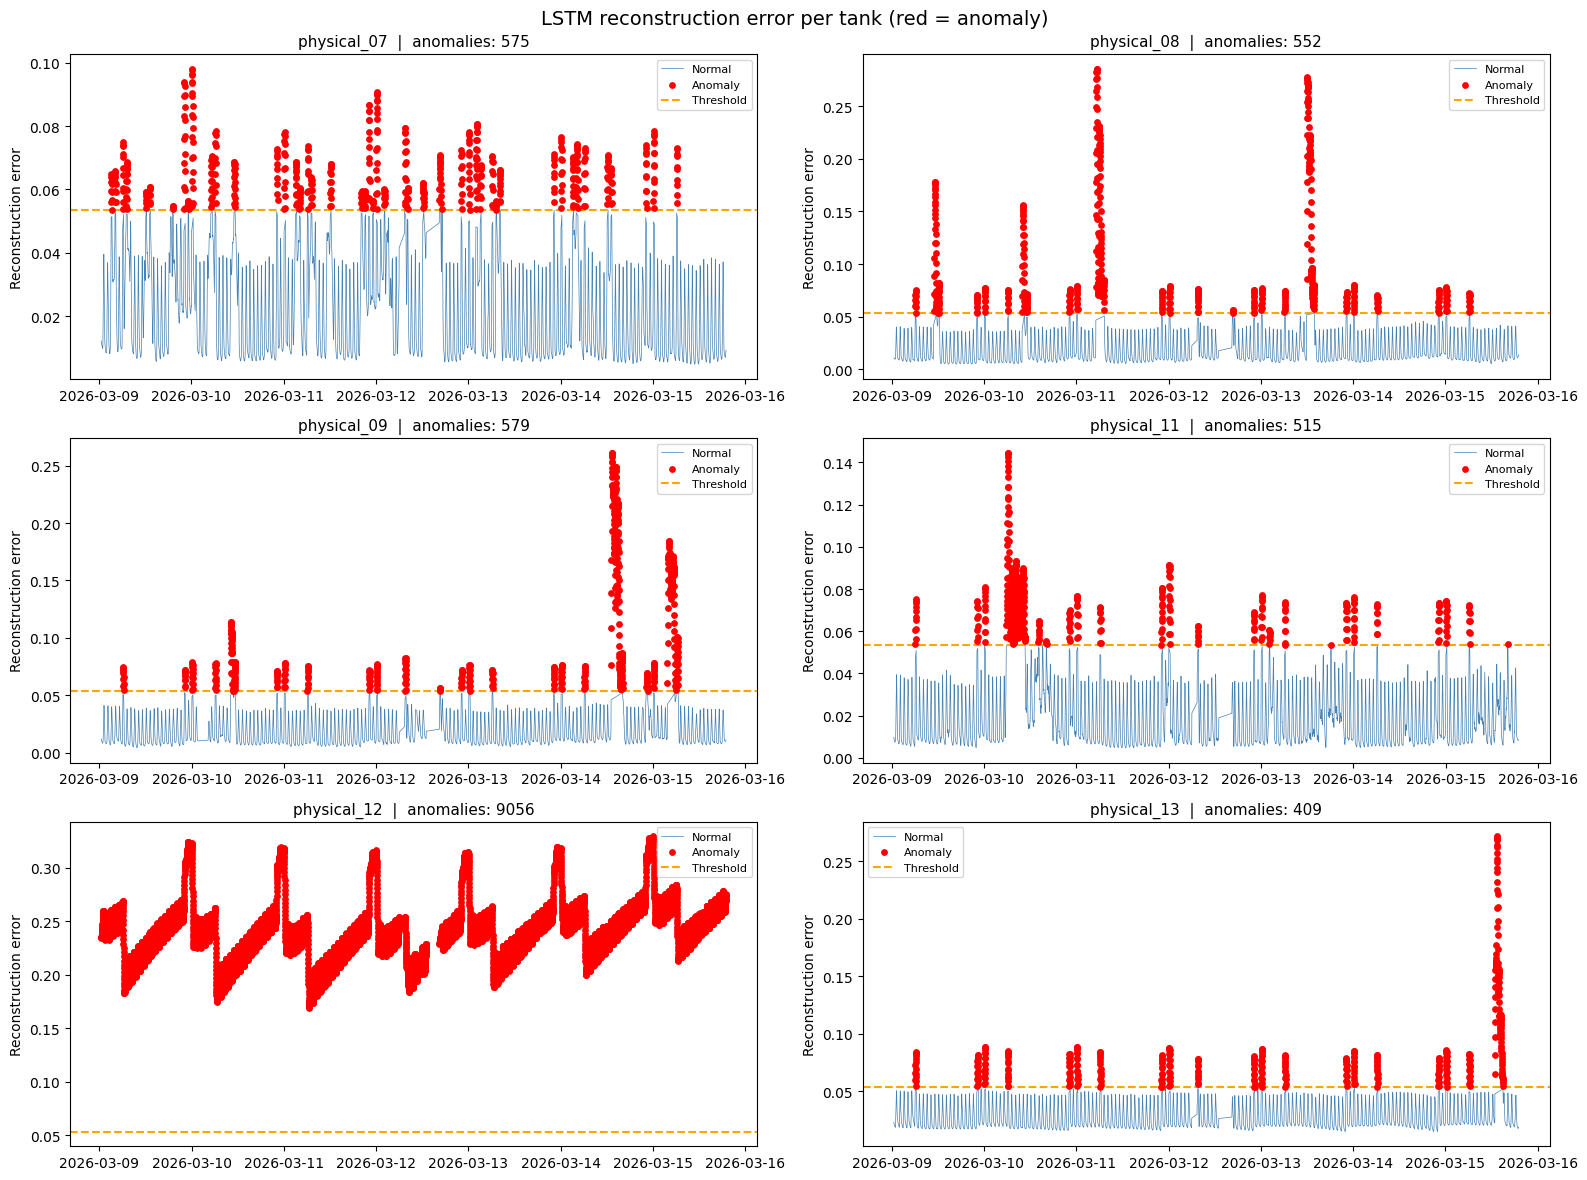

In [ ]:
# Plot reconstruction error over time per tank
fig, axes = plt.subplots(3, 2, figsize=(16, 12))
axes = axes.flatten()

for i, (tank, group) in enumerate(meta_df.groupby('tank_id')):
    normal  = group[group['is_anomaly']==0]
    anomaly = group[group['is_anomaly']==1]

    axes[i].plot(normal['datetime'],  normal['recon_error'],
                 color='steelblue', linewidth=0.5, label='Normal')
    axes[i].scatter(anomaly['datetime'], anomaly['recon_error'],
                    color='red', s=15, zorder=5, label='Anomaly')
    axes[i].axhline(y=THRESHOLD, color='orange', linestyle='--',
                    linewidth=1.5, label='Threshold')
    axes[i].set_title(f'{tank}  |  anomalies: {len(anomaly)}', fontsize=11)
    axes[i].set_ylabel('Reconstruction error')
    axes[i].legend(fontsize=8)

plt.suptitle('LSTM reconstruction error per tank (red = anomaly)', fontsize=14)
plt.tight_layout()
plt.show()

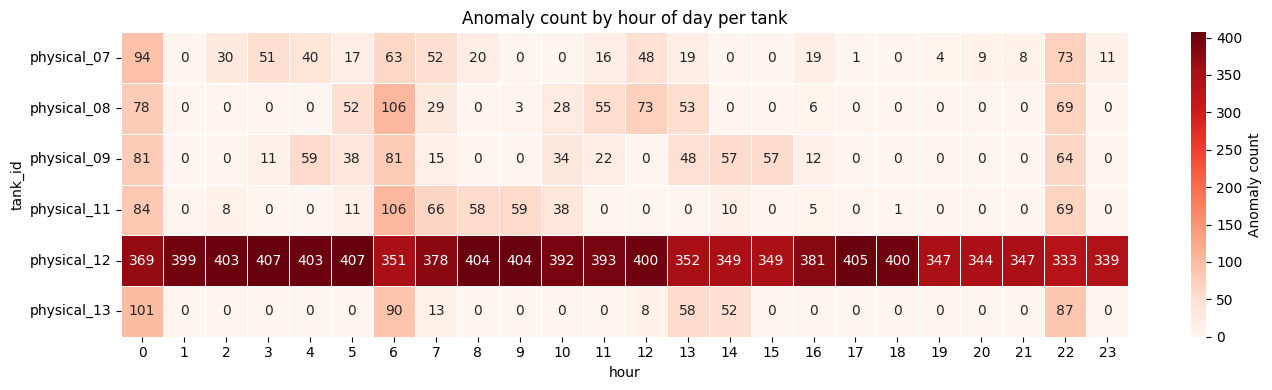

In [ ]:
# Heatmap: anomaly count by hour per tank
pivot = meta_df[meta_df['is_anomaly']==1].copy()
pivot['hour'] = pd.to_datetime(pivot['datetime']).dt.hour
pivot = pivot.groupby(['tank_id','hour']).size().unstack(fill_value=0)

plt.figure(figsize=(14, 4))
sns.heatmap(pivot, cmap='Reds', linewidths=0.5,
            annot=True, fmt='d', cbar_kws={'label':'Anomaly count'})
plt.title('Anomaly count by hour of day per tank', fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
# Top 10 worst anomalies
print('Top 10 most anomalous sequences:')
meta_df[meta_df['is_anomaly']==1].nsmallest(10, 'recon_error').sort_values('recon_error', ascending=False)[[
    'datetime','tank_id','recon_error'
]]

Top 10 most anomalous sequences:


,datetime,tank_id,recon_error
13863,2026-03-12 22:09:00,physical_08,0.053700
30357,2026-03-11 22:07:00,physical_11,0.053693
12898,2026-03-12 00:22:00,physical_08,0.053692
152,2026-03-09 03:19:00,physical_07,0.053682
5092,2026-03-13 00:19:00,physical_07,0.053678
9500,2026-03-09 12:24:00,physical_08,0.053660
32601,2026-03-13 18:13:00,physical_11,0.053644
5470,2026-03-13 07:12:00,physical_07,0.053639
13558,2026-03-12 16:43:00,physical_08,0.053608
9482,2026-03-09 12:05:00,physical_08,0.053607


---
## Step 12 — Save Model & Artifacts

In [ ]:
# Save model
model.save('tank_lstm_model.h5')

# Save scalers (one per tank)
joblib.dump(scalers, 'tank_lstm_scalers.pkl')

# Save threshold
joblib.dump({
    'threshold'  : float(THRESHOLD),
    'seq_len'    : SEQ_LEN,
    'n_features' : N_FEATURES,
    'features'   : FEATURES
}, 'tank_lstm_config.pkl')

# Save predictions
meta_df.to_csv('tank_lstm_predictions.csv', index=False)

print('Saved: tank_lstm_model.h5')
print('Saved: tank_lstm_scalers.pkl')
print('Saved: tank_lstm_config.pkl')
print('Saved: tank_lstm_predictions.csv')

Saved: tank_lstm_model.h5
Saved: tank_lstm_scalers.pkl
Saved: tank_lstm_config.pkl
Saved: tank_lstm_predictions.csv


---
## Step 13 — Flask API for n8n
The API maintains a **rolling buffer** of the last 30 readings per tank.  
Each new reading is appended, a sequence is formed, and the model scores it.

In [ ]:
flask_code = '''
from flask import Flask, request, jsonify
from collections import deque
import numpy as np
import joblib
from tensorflow.keras.models import load_model

app     = Flask(__name__)
model   = load_model("tank_lstm_model.keras")
scalers = joblib.load("tank_lstm_scalers.pkl")
config  = joblib.load("tank_lstm_config.pkl")

THRESHOLD  = config["threshold"]
SEQ_LEN    = config["seq_len"]
FEATURES   = config["features"]

# Rolling buffer: last 30 readings per tank
buffers = {tank: deque(maxlen=SEQ_LEN) for tank in scalers}

@app.route("/predict", methods=["POST"])
def predict():
    d       = request.json
    tank_id = d["tank_id"]
    scaler  = scalers[tank_id]

    # Scale the new reading
    raw     = np.array([[d[f] for f in FEATURES]])
    scaled  = scaler.transform(raw)[0]

    # Append to buffer
    buffers[tank_id].append(scaled)

    # Need full sequence before scoring
    if len(buffers[tank_id]) < SEQ_LEN:
        return jsonify({
            "tank_id"     : tank_id,
            "status"      : "buffering",
            "buffer_size" : len(buffers[tank_id]),
            "needed"      : SEQ_LEN
        })

    # Build sequence and predict
    seq   = np.array(list(buffers[tank_id]))[np.newaxis, :, :]
    recon = model.predict(seq, verbose=0)
    error = float(np.mean(np.abs(recon - seq)))

    return jsonify({
        "tank_id"     : tank_id,
        "recon_error" : round(error, 6),
        "threshold"   : round(THRESHOLD, 6),
        "is_anomaly"  : int(error > THRESHOLD)
    })

if __name__ == "__main__":
    app.run(host="0.0.0.0", port=5000)
'''
with open('app_lstm.py', 'w') as f:
    f.write(flask_code.strip())
print('Saved: app_lstm.py  |  Run with: python app_lstm.py')

Saved: app_lstm.py  |  Run with: python app_lstm.py


In [ ]:
import tensorflow as tf
import keras

print("TensorFlow:", tf.__version__)
print("Keras:", keras.__version__)

TensorFlow: 2.16.1
Keras: 3.12.1


In [ ]:
import h5py
import json
import numpy as np

with h5py.File('tank_lstm_model.h5', 'r') as f:

    # Check quantization_config issue
    config_str = f.attrs['model_config']
    if 'quantization_config' in config_str:
        print("❌ quantization_config found — will crash on HuggingFace")
    else:
        print("✅ No quantization_config — safe to upload")

    # Check weight layers
    print("\nLayers in model:")
    def print_layers(name):
        print(" ", name)
    f.visit(print_layers)

# Check scalers for physical_01
import joblib
scalers = joblib.load('tank_lstm_scalers.pkl')

print("\n--- physical_01 scaler range ---")
scaler = scalers['physical_01']
print(f"level_feet min: {scaler.data_min_[0]:.4f}")
print(f"level_feet max: {scaler.data_max_[0]:.4f}")
print(f"\nAll tank level ranges:")
for tank, s in scalers.items():
    print(f"  {tank}: {s.data_min_[0]:.2f} to {s.data_max_[0]:.2f} feet")

✅ No quantization_config — safe to upload

Layers in model:
  model_weights
  model_weights/decoder_lstm1
  model_weights/decoder_lstm1/decoder_lstm1
  model_weights/decoder_lstm1/decoder_lstm1/lstm_cell
  model_weights/decoder_lstm1/decoder_lstm1/lstm_cell/bias
  model_weights/decoder_lstm1/decoder_lstm1/lstm_cell/kernel
  model_weights/decoder_lstm1/decoder_lstm1/lstm_cell/recurrent_kernel
  model_weights/decoder_lstm2
  model_weights/decoder_lstm2/decoder_lstm2
  model_weights/decoder_lstm2/decoder_lstm2/lstm_cell
  model_weights/decoder_lstm2/decoder_lstm2/lstm_cell/bias
  model_weights/decoder_lstm2/decoder_lstm2/lstm_cell/kernel
  model_weights/decoder_lstm2/decoder_lstm2/lstm_cell/recurrent_kernel
  model_weights/encoder_input
  model_weights/encoder_lstm1
  model_weights/encoder_lstm1/encoder_lstm1
  model_weights/encoder_lstm1/encoder_lstm1/lstm_cell
  model_weights/encoder_lstm1/encoder_lstm1/lstm_cell/bias
  model_weights/encoder_lstm1/encoder_lstm1/lstm_cell/kernel
  model_